In [2]:
import cftime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
from scipy import interpolate
from scipy import io
from scipy import ndimage
import xarray as xr
import cmocean 

%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Load mission 19 to get the metadata of the mission
mission_nc_path = '../../../data/swift/doi_10_5061_dryad_hx3ffbgk0__v20230321/mission_19.nc'
mission_dataset = nc.Dataset(mission_nc_path, mode='r')
mission19_time = np.median(mission_dataset['time'][:])
mission19_time_datetime = cftime.num2pydate(mission19_time, 
                                     units=mission_dataset['time'].units, 
                                     calendar=mission_dataset['time'].calendar)

In [ ]:
mission_df_8m = pd.read_csv('../../data/mission_df.csv')
mission_df_8m

50.0
950.0
-100.0
1100.0


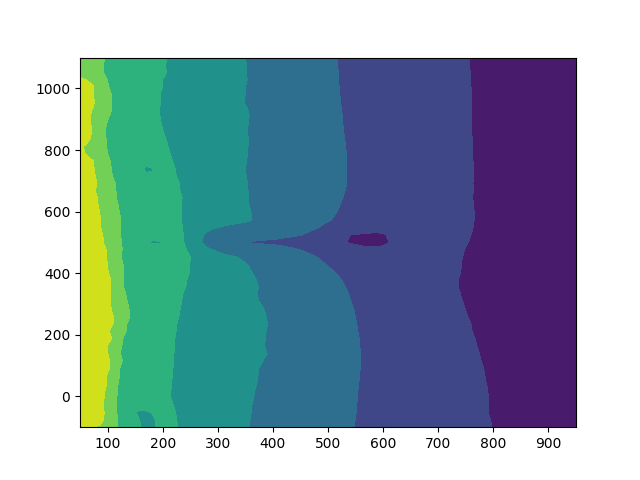

In [5]:
# Load basic processed bathymetry
bathy_basic_data = nc.Dataset('../../data/FRF_geomorphology_DEMs_surveyDEM_20211021.nc')
xFRF = bathy_basic_data['xFRF'][:]
yFRF = bathy_basic_data['yFRF'][:]
bathy_x_grid, bathy_y_grid = np.meshgrid(xFRF, yFRF)
elevation_basic = bathy_basic_data['elevation'][0,:,:]
print(np.min(xFRF))
print(np.max(xFRF))
print(np.min(yFRF))
print(np.max(yFRF))

fig, ax = plt.subplots()
ax.contourf(bathy_x_grid, bathy_y_grid, elevation_basic)


900
900
(1800, 900)
Values to put in SWAN input file 899 899


Text(0.5, 0.98, 'Bathy Meshgrid')

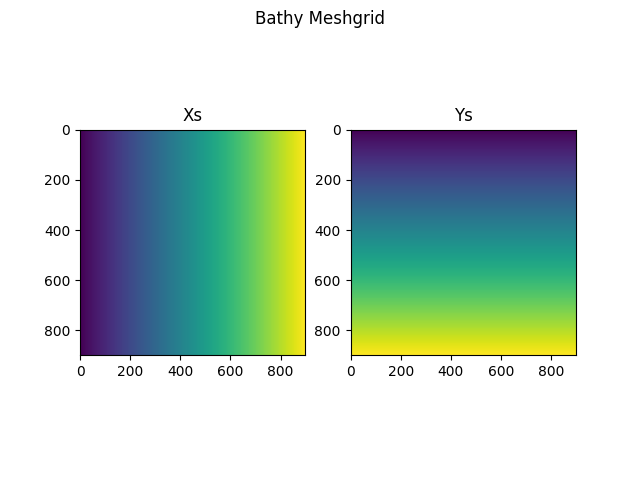

In [18]:
# Define grid cell edge size
x_cgrid_size = 1 # units are meters
y_cgrid_size = 1 # units are meters

# Define grid edges
x_cgrid_min = 50
x_cgrid_max = 950
y_cgrid_min = 100
y_cgrid_max = 1000

# Define number of points based on grid size
num_x_points = int((x_cgrid_max - x_cgrid_min) / x_cgrid_size)
print(num_x_points)
num_y_points = int((y_cgrid_max - y_cgrid_min) / y_cgrid_size)
print(num_y_points)

# Create mesh grid
x_cgrid, y_cgrid = np.meshgrid(np.linspace(x_cgrid_min, x_cgrid_max, num_x_points),
                               np.linspace(y_cgrid_min, y_cgrid_max, num_y_points))

# Stack the x grid and y grid to be read into swan
swan_cgrid = np.concatenate((x_cgrid, y_cgrid), axis=0)
print(swan_cgrid.shape)

with open('./cgrid_m19m21.xy', 'w') as file:
    for x in x_cgrid.flatten():
        file.write(f"{x:18.12f}\n")
    for y in y_cgrid.flatten():
        file.write(f"{y:18.12f}\n")

# Save the grid to load in for analysis
io.savemat('.cgrid_m19m21.mat', {'x_cgrid':x_cgrid, 'y_cgrid':y_cgrid})

print(f'Values to put in SWAN input file {num_x_points-1} {num_y_points-1}')

fig, axs = plt.subplots(1, 2)
axs[0].imshow(x_cgrid)
axs[0].set_title('Xs')
axs[1].imshow(y_cgrid)
axs[1].set_title('Ys')
fig.suptitle('Bathy Meshgrid')

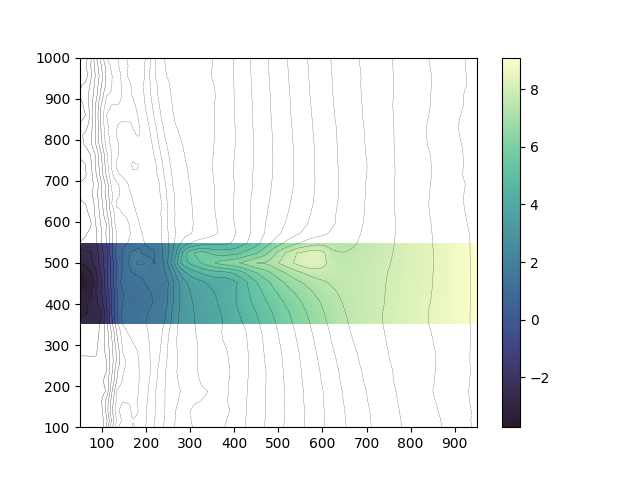

In [19]:
elevation_regridded = interpolate.interpn((xFRF, yFRF), elevation_basic.T, (x_cgrid, y_cgrid), method='linear', fill_value=0)
fig, ax = plt.subplots()
im = ax.pcolormesh(x_cgrid[250:450, :], y_cgrid[250:450, :], -elevation_regridded[250:449,:-1], shading='flat', cmap=cmocean.cm.deep_r)
ax.contour(x_cgrid, y_cgrid, elevation_regridded, colors='k', levels=25, linewidths=0.2)
fig.colorbar(im)


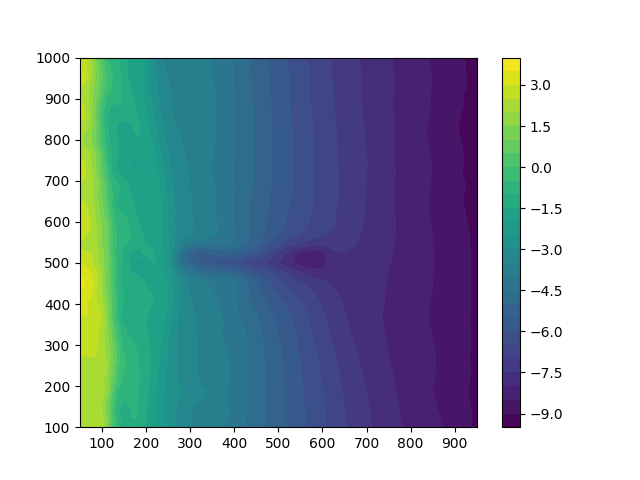

In [22]:
fig, ax = plt.subplots()
# im = ax.pcolormesh(x_cgrid[250:450, :], y_cgrid[250:450, :], -elevation_regridded[250:449,:-1], shading='flat', cmap=cmocean.cm.deep_r)
im = ax.contourf(x_cgrid, y_cgrid, elevation_regridded, levels=25)
fig.colorbar(im)


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_37392/3035590201.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


False
(900, 900)


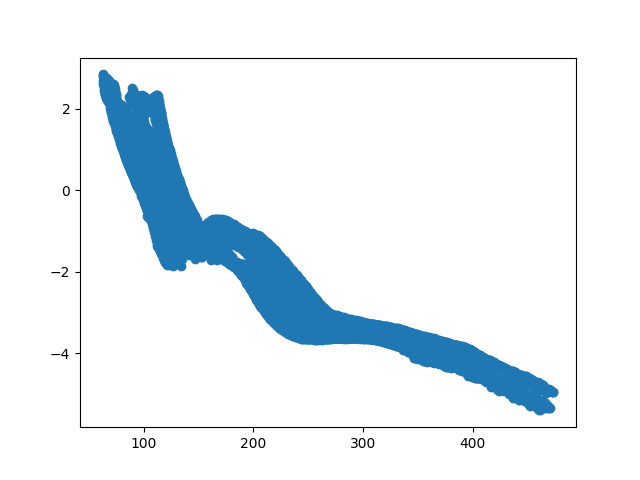

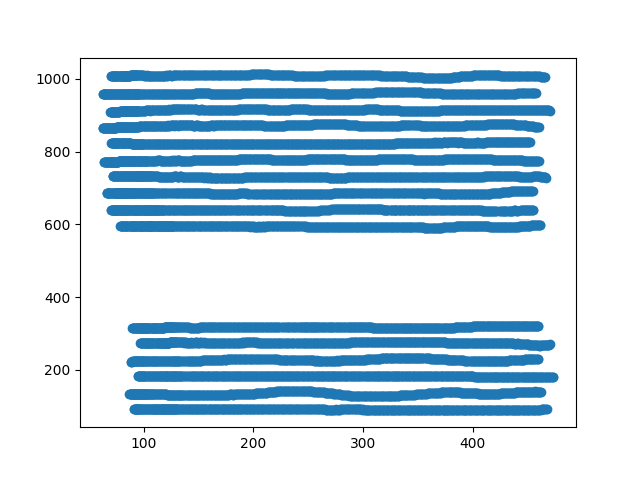

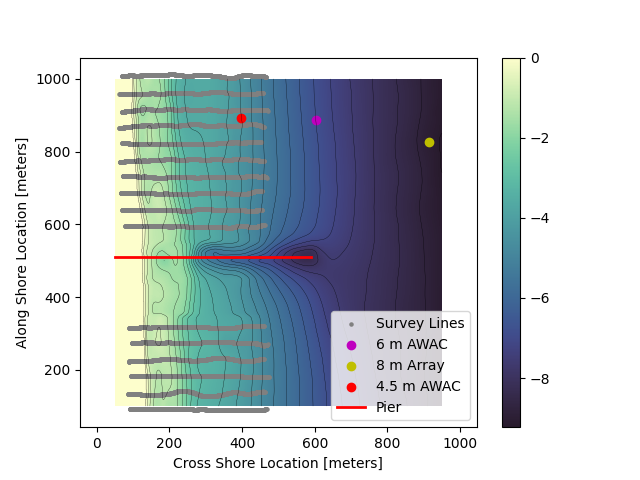

In [26]:
# Load the bathymetry data from closest to Mission 19
bathy_20211008 = nc.Dataset('../../data/FRF_geomorphology_elevationTransects_survey_20211008.nc')

# Get the point cloud data from the transect file
xFRF_survey_points = bathy_20211008['xFRF'][:]
yFRF_survey_points = bathy_20211008['yFRF'][:]
elevation_survey_points = bathy_20211008['elevation'][:]

fig, ax = plt.subplots()
ax.scatter(xFRF_survey_points, elevation_survey_points)

fig, ax = plt.subplots()
ax.scatter(xFRF_survey_points, yFRF_survey_points)

# Interpolate the sruvey points onto the same grid as the computational grid
zgrid = interpolate.griddata((xFRF_survey_points, yFRF_survey_points), elevation_survey_points,
                             (x_cgrid, y_cgrid), method='linear', fill_value=0)

# Synthetically fill in the bathymetry from the regridded full survey
zgrid[250:450,:] = elevation_regridded[250:450,:]
zgrid[:,400:] = elevation_regridded[:,400:]

# Flip the bathy sign
swandepth = -zgrid
swandepth = np.nan_to_num(swandepth, copy=False)

# smooth bathy
swandepth = ndimage.gaussian_filter(swandepth, sigma=5)
swandepth[swandepth < 0.1 ] = 0.0

fig, ax = plt.subplots()
im = ax.pcolormesh(x_cgrid, y_cgrid, -swandepth[:-1,:-1], shading='flat', cmap=cmocean.cm.deep_r)
ax.contour(x_cgrid, y_cgrid, swandepth, colors='k', levels=25, linewidths=0.2)
ax.scatter(xFRF_survey_points, yFRF_survey_points, color='gray', s=5, label='Survey Lines')
fig.colorbar(im)
 # Figure properties
awac4p5m_location = [397.35, 890.98] # Converted from lat lon locations
                                     # published on FRF data portal
awac6m_location = [603.12, 886.68]   # Converted from lat lon locations published on FRF data portal
array8m_location = [914.05, 826.08]  # Nominal location based on published data even though this array has multiple locations
ax.scatter(awac6m_location[0], awac6m_location[1], color='m', label='6 m AWAC')
ax.scatter(array8m_location[0], array8m_location[1], color='y', label='8 m Array')
ax.scatter(awac4p5m_location[0],awac4p5m_location[1],
            color='r', label='4.5 m AWAC')
ax.set_aspect('equal')
ax.set_xlabel('Cross Shore Location [meters]')
ax.set_ylabel('Along Shore Location [meters]')
ax.plot([50,591],[510,510], linewidth=2, color='r', label='Pier')
ax.legend()
ax.axis('equal')

# Number of nan values 
print(np.any(np.isnan(swandepth)))

# Set below depth min points to exception value
swandepth_small = swandepth.copy()
swandepth_small[swandepth_small < 0.1] = -999

# Save the bathy data as a text file 
depth_fname = './depth_m19m21.dep'
np.savetxt(depth_fname, swandepth_small, fmt="%011.8f", )

print(swandepth_small.shape)